# Single Image Exploration

A hands-on sandbox to understand the full pipeline on one image before committing to the full dataset.

> **Image used:** `sample/test_image.jpg` — place any cricket image with at least one visible jersey there.

## Setup

In [1]:
# --- progress helpers (added) ---------------------------------------------
import time as _time
from contextlib import contextmanager
@contextmanager
def step(msg):
    print(f'\u23f3 {msg} ...', end='', flush=True); _t0=_time.time()
    try:
        yield
    finally:
        print(f'\r\u2705 {msg} \u2014 done in {_time.time()-_t0:.1f}s'+' '*8, flush=True)
def progress(i, n, label=''):
    print(f'\r   [{i:>3}/{n}] {label:<24}', end='', flush=True)
    if i==n: print()
# --------------------------------------------------------------------------

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2hsv
from skimage import exposure

## Step 1 — Load & Inspect the Image

Shape: (853, 1280, 3)


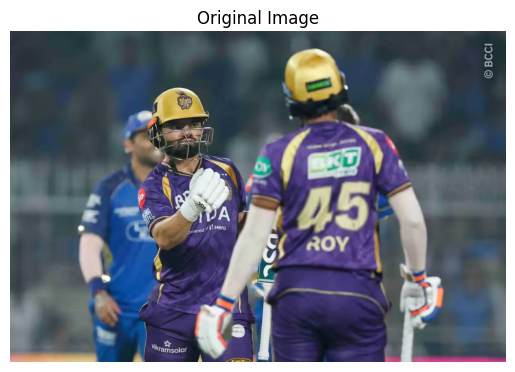

In [2]:
img = cv2.imread("../sample images/test_image.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Shape:", img.shape)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

**Resize to 800×600 if needed:**

In [3]:
if img.shape[:2] != (600, 800):
    img = cv2.resize(img, (800, 600), interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("Resized to 800x600")

print("Final shape:", img.shape)

Resized to 800x600
Final shape: (600, 800, 3)


## Step 2 — Draw the 8×8 Grid

Visualize all 64 cells overlaid on the image. Each cell is 100×75 px.

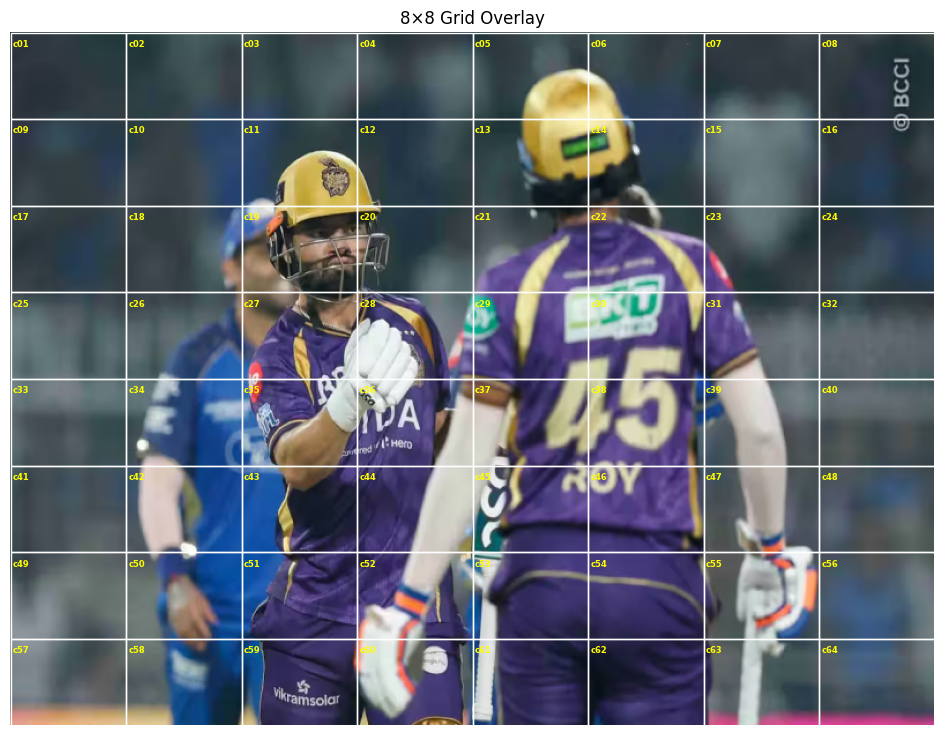

In [4]:
GRID_ROWS, GRID_COLS = 8, 8
CELL_W, CELL_H = 800 // GRID_COLS, 600 // GRID_ROWS   # 100 x 75

fig, ax = plt.subplots(1, 1, figsize=(12, 9))
ax.imshow(img_rgb)

for r in range(GRID_ROWS):
    for c in range(GRID_COLS):
        cell_idx = r * GRID_COLS + c + 1  # 1-based (c01 to c64)
        x, y = c * CELL_W, r * CELL_H
        rect = patches.Rectangle((x, y), CELL_W, CELL_H,
                                  linewidth=1, edgecolor='white', facecolor='none')
        ax.add_patch(rect)
        ax.text(x + 2, y + 12, f"c{cell_idx:02d}",
                color='yellow', fontsize=6, fontweight='bold')

plt.title("8×8 Grid Overlay")
plt.axis("off")
plt.show()

## Step 3 — Extract a Single Cell

Crop cell `c29` (row 4, col 5 — 0-indexed: row=3, col=4) as an example.

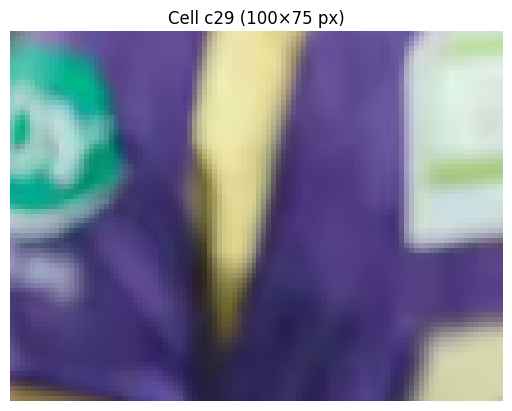

In [5]:
def get_cell(img, cell_idx_1based):
    """cell_idx_1based: 1 to 64, left-to-right top-to-bottom."""
    idx = cell_idx_1based - 1
    row = idx // GRID_COLS
    col = idx % GRID_COLS
    y1, y2 = row * CELL_H, (row + 1) * CELL_H
    x1, x2 = col * CELL_W, (col + 1) * CELL_W
    return img[y1:y2, x1:x2]

cell = get_cell(img_rgb, 29)
plt.imshow(cell)
plt.title("Cell c29 (100×75 px)")
plt.axis("off")
plt.show()

## Step 4 — Feature Extraction on the Cell

### 4a. Color Histogram (HSV)

Color feature vector length: 96


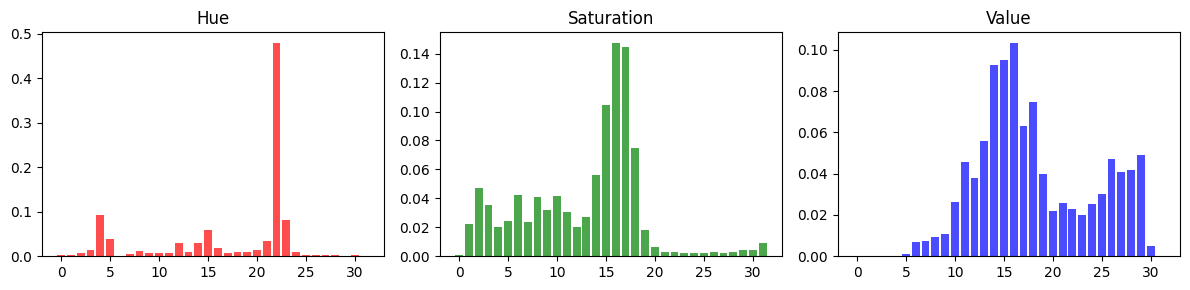

In [6]:
cell_hsv = rgb2hsv(cell)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
channel_names = ["Hue", "Saturation", "Value"]
colors = ["r", "g", "b"]
feature_color = []

for i, (ax, name, col) in enumerate(zip(axes, channel_names, colors)):
    hist, _ = np.histogram(cell_hsv[:, :, i], bins=32, range=(0, 1))
    hist = hist / hist.sum()  # normalize
    feature_color.extend(hist.tolist())
    ax.bar(range(32), hist, color=col, alpha=0.7)
    ax.set_title(name)

print("Color feature vector length:", len(feature_color))  # 96
plt.tight_layout()
plt.show()

### 4b. HOG Features

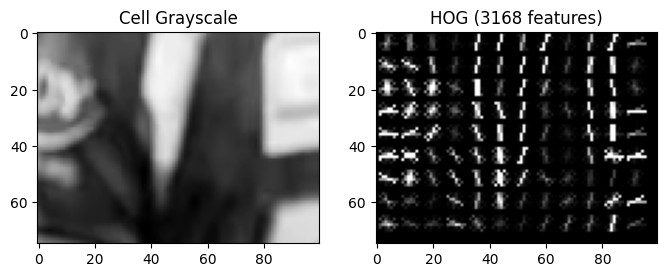

In [7]:
cell_gray = cv2.cvtColor(cell, cv2.COLOR_RGB2GRAY)

hog_features, hog_image = hog(
    cell_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    feature_vector=True
)

hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(cell_gray, cmap='gray'); ax1.set_title("Cell Grayscale")
ax2.imshow(hog_image_rescaled, cmap='gray'); ax2.set_title(f"HOG ({len(hog_features)} features)")
plt.show()

### 4c. LBP Features

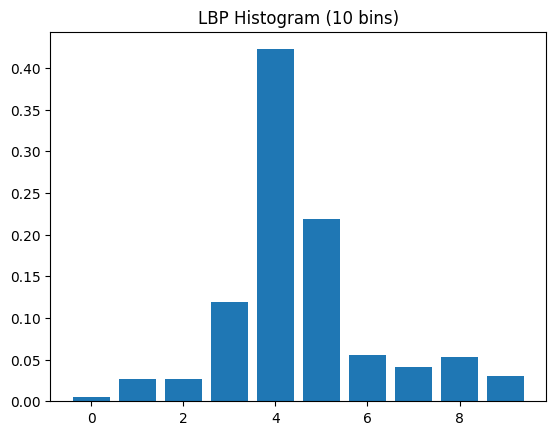

In [8]:
lbp = local_binary_pattern(cell_gray, P=8, R=1, method='uniform')
lbp_hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
lbp_hist = lbp_hist / lbp_hist.sum()

plt.bar(range(10), lbp_hist)
plt.title("LBP Histogram (10 bins)")
plt.show()

### 4d. Combine into One Feature Vector

In [9]:
full_feature = np.concatenate([feature_color, hog_features, lbp_hist])
print("Total feature vector length:", len(full_feature))

Total feature vector length: 3274


## Step 5 — Compare Two Cells Side-by-Side

Pick one cell that clearly has a jersey (e.g., `c29`) and one background cell (e.g., `c01`).

> **Tip:** Adjust the cell indices below to match your image.

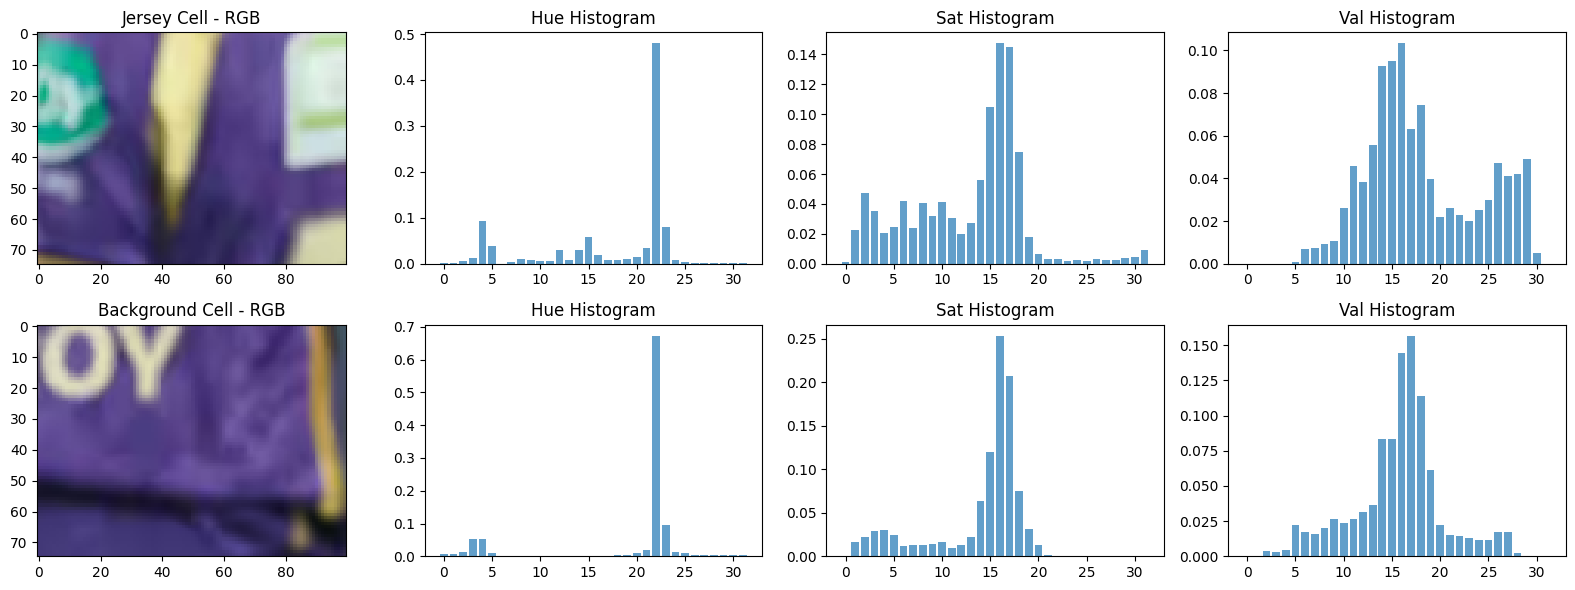

In [10]:
cell_jersey = get_cell(img_rgb, 29)   # adjust to a cell with jersey
cell_bg     = get_cell(img_rgb, 46)    # adjust to a background cell

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for row_idx, (cell, title) in enumerate([(cell_jersey, "Jersey Cell"), (cell_bg, "Background Cell")]):
    cell_hsv = rgb2hsv(cell)
    cell_gray = cv2.cvtColor(cell, cv2.COLOR_RGB2GRAY)

    axes[row_idx][0].imshow(cell); axes[row_idx][0].set_title(f"{title} - RGB")

    for ch, name in enumerate(["Hue", "Sat", "Val"]):
        hist, _ = np.histogram(cell_hsv[:, :, ch], bins=32, range=(0, 1))
        axes[row_idx][ch + 1].bar(range(32), hist / hist.sum(), alpha=0.7)
        axes[row_idx][ch + 1].set_title(f"{name} Histogram")

plt.tight_layout()
plt.show()

**What to look for:** Jersey cells from the same team should have similar hue peaks. Background cells should look flat/random.

## Step 6 — Full Image: Extract Features for All 64 Cells

In [11]:
def extract_cell_features(cell_rgb):
    cell_hsv = rgb2hsv(cell_rgb)
    cell_gray = cv2.cvtColor(cell_rgb, cv2.COLOR_RGB2GRAY)

    color_hist = []
    for ch in range(3):
        h, _ = np.histogram(cell_hsv[:, :, ch], bins=32, range=(0, 1))
        color_hist.extend((h / h.sum()).tolist())

    hog_feats = hog(cell_gray, orientations=9, pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2), feature_vector=True)

    lbp = local_binary_pattern(cell_gray, P=8, R=1, method='uniform')
    lbp_h, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
    lbp_h = lbp_h / lbp_h.sum()

    return np.concatenate([color_hist, hog_feats, lbp_h])

all_features = []
print('Extracting handcrafted features for all 64 cells...')
for i in range(1, 65):
    cell = get_cell(img_rgb, i)
    all_features.append(extract_cell_features(cell))
    progress(i, 64, f'cell c{i:02d}')

all_features = np.array(all_features)
print("Feature matrix shape:", all_features.shape)  # (64, feature_dim)

Extracting handcrafted features for all 64 cells...
   [ 64/64] cell c64                
Feature matrix shape: (64, 3274)


## Step 7 — Visualize Dominant Hue per Cell (Quick Team Hint)

Before any model, use dominant hue to see which cells are "colorful" (likely jersey) vs neutral (background).

Computing dominant hue per cell...
   [ 64/64] cell c64                


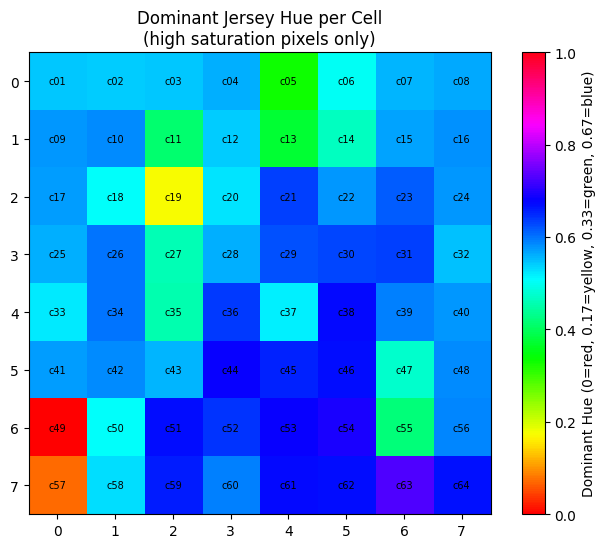

In [12]:
dominant_hue = []
print('Computing dominant hue per cell...')
for i in range(1, 65):
    progress(i, 64, f'cell c{i:02d}')
    cell = get_cell(img_rgb, i)
    hsv = rgb2hsv(cell)
    # high saturation pixels are likely jersey, not background
    mask = hsv[:, :, 1] > 0.3
    if mask.sum() > 10:
        dominant_hue.append(hsv[:, :, 0][mask].mean())
    else:
        dominant_hue.append(0)  # no strong color = background

hue_grid = np.array(dominant_hue).reshape(8, 8)

plt.figure(figsize=(8, 6))
plt.imshow(hue_grid, cmap='hsv', vmin=0, vmax=1)
plt.colorbar(label="Dominant Hue (0=red, 0.17=yellow, 0.33=green, 0.67=blue)")
plt.title("Dominant Jersey Hue per Cell\n(high saturation pixels only)")
for r in range(8):
    for c in range(8):
        plt.text(c, r, f"c{r*8+c+1:02d}", ha='center', va='center',
                 fontsize=7, color='black')
plt.show()

## Step 8 — Additional Feature Techniques

### 8a. LAB Color Histogram

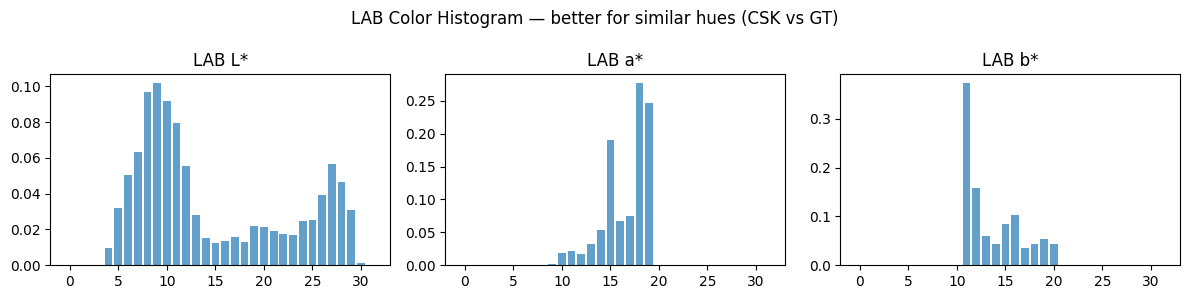

In [13]:
cell = get_cell(img_rgb, 29)
cell_lab = cv2.cvtColor(cell, cv2.COLOR_RGB2LAB)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
names = ["L*", "a*", "b*"]
ranges = [(0, 256), (0, 256), (0, 256)]

for i, (ax, name, r) in enumerate(zip(axes, names, ranges)):
    hist, _ = np.histogram(cell_lab[:, :, i], bins=32, range=r)
    hist = hist / hist.sum()
    ax.bar(range(32), hist, alpha=0.7)
    ax.set_title(f"LAB {name}")

plt.suptitle("LAB Color Histogram — better for similar hues (CSK vs GT)")
plt.tight_layout()
plt.show()

### 8b. Color Moments (HSV)

In [14]:
cell_hsv_cv = cv2.cvtColor(cell, cv2.COLOR_RGB2HSV).astype(np.float32)

means = cell_hsv_cv.mean(axis=(0, 1))
stds  = cell_hsv_cv.std(axis=(0, 1))
skews = ((cell_hsv_cv - means) ** 3).mean(axis=(0, 1)) / (stds ** 3 + 1e-6)

color_moments = np.concatenate([means, stds, skews])
print("Color moments (9 values):", np.round(color_moments, 2))

Color moments (9 values): [ 1.0180e+02  1.0624e+02  1.4875e+02  3.8770e+01  4.7690e+01  4.6790e+01
 -1.0800e+00 -9.0000e-02  4.1000e-01]


### 8c. Dominant Colors via K-Means

✅ Running K-Means (3 clusters) on cell pixels — done in 0.2s        


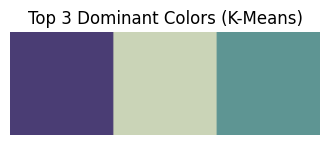

RGB centers: [[ 74  61 116]
 [202 212 183]
 [ 94 149 147]]


In [15]:
from sklearn.cluster import KMeans

pixels = cell.reshape(-1, 3).astype(np.float32)
km = KMeans(n_clusters=3, n_init=5, random_state=0)
with step('Running K-Means (3 clusters) on cell pixels'):
    km.fit(pixels)

centers = km.cluster_centers_.astype(int)
counts  = np.bincount(km.labels_)
order   = counts.argsort()[::-1]

swatch = np.zeros((50, 150, 3), dtype=np.uint8)
for i, idx in enumerate(order):
    swatch[:, i*50:(i+1)*50] = centers[idx]

plt.figure(figsize=(4, 1.5))
plt.imshow(swatch)
plt.axis("off")
plt.title("Top 3 Dominant Colors (K-Means)")
plt.show()
print("RGB centers:", centers[order])

### 8d. GLCM Texture

In [16]:
from skimage.feature import graycomatrix, graycoprops

cell_gray = cv2.cvtColor(cell, cv2.COLOR_RGB2GRAY)
levels = 64
cell_gray_q = (cell_gray // (256 // levels)).astype(np.uint8)

glcm = graycomatrix(cell_gray_q, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                    levels=levels, symmetric=True, normed=True)

props = {}
for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
    props[prop] = graycoprops(glcm, prop).ravel()
    print(f"{prop}: {np.round(props[prop], 3)}")

glcm_feats = np.concatenate(list(props.values()))
print("GLCM feature length:", len(glcm_feats))

contrast: [ 6.451 10.196  2.952  8.021]
homogeneity: [0.609 0.549 0.683 0.535]
energy: [0.099 0.094 0.111 0.089]
correlation: [0.986 0.977 0.993 0.982]
GLCM feature length: 16


### 8e. Gabor Filter Bank

In [17]:
from skimage.filters import gabor

freqs = [0.1, 0.25, 0.4]
thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]

gabor_feats = []
for freq in freqs:
    for theta in thetas:
        real, imag = gabor(cell_gray.astype(float) / 255.0, frequency=freq, theta=theta)
        gabor_feats += [real.mean(), real.std(), imag.mean(), imag.std()]

gabor_feats = np.array(gabor_feats)
print("Gabor feature length:", len(gabor_feats))
print("First 8:", np.round(gabor_feats[:8], 4))

Gabor feature length: 48
First 8: [ 0.0004  0.0141 -0.0001  0.0141  0.0003  0.0065  0.      0.0065]


---

## What You've Learned After This Exploration

- How the 8×8 grid maps to actual image regions
- What feature vectors look like for jersey vs background cells
- That HSV color histograms are the most team-discriminative feature (jersey colors are strong and saturated)
- HOG adds texture/shape info that helps when colors are similar (e.g., CSK yellow vs GT gold)
- You now have the building blocks to wire up the full pipeline in Phase 3